# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
df = pd.read_csv("cancer.csv")

In [3]:
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [4]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [5]:
df.dtypes

ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [7]:
## Bare Nuclei                    699 non-null object , this column has some issue, analyze

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [8]:
# We could see "?" values in column, this should be removed from data set
# Check for missing value in any other column

In [9]:
#Some values in Bare Nuclei is not integer, check what is that.
df['Bare Nuclei'].unique()

array(['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6'],
      dtype=object)

In [10]:
# No missing values found. So let us try to remove ? from bare nuclei column
# Get count of rows having ?

In [11]:
#Replace ? with nan
df = df.replace('?', np.nan)

In [12]:
df.isnull().sum(), df.shape

(ID                              0
 ClumpThickness                  0
 Cell Size                       0
 Cell Shape                      0
 Marginal Adhesion               0
 Single Epithelial Cell Size     0
 Bare Nuclei                    16
 Normal Nucleoli                 0
 Bland Chromatin                 0
 Mitoses                         0
 Class                           0
 dtype: int64, (699, 11))

In [13]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [14]:
fill_val = int(df['Bare Nuclei'].median())
fill_val

1

In [15]:
df['Bare Nuclei'].fillna(fill_val, inplace=True)
df.isnull().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [16]:
df['Bare Nuclei'] = df['Bare Nuclei'].astype('int64') 

In [17]:
df.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.486409,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.621929,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [18]:
#check the types again
df.dtypes

ID                             int64
ClumpThickness                 int64
Cell Size                      int64
Cell Shape                     int64
Marginal Adhesion              int64
Single Epithelial Cell Size    int64
Bare Nuclei                    int64
Normal Nucleoli                int64
Bland Chromatin                int64
Mitoses                        int64
Class                          int64
dtype: object

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [19]:
# Check for correlation of variable

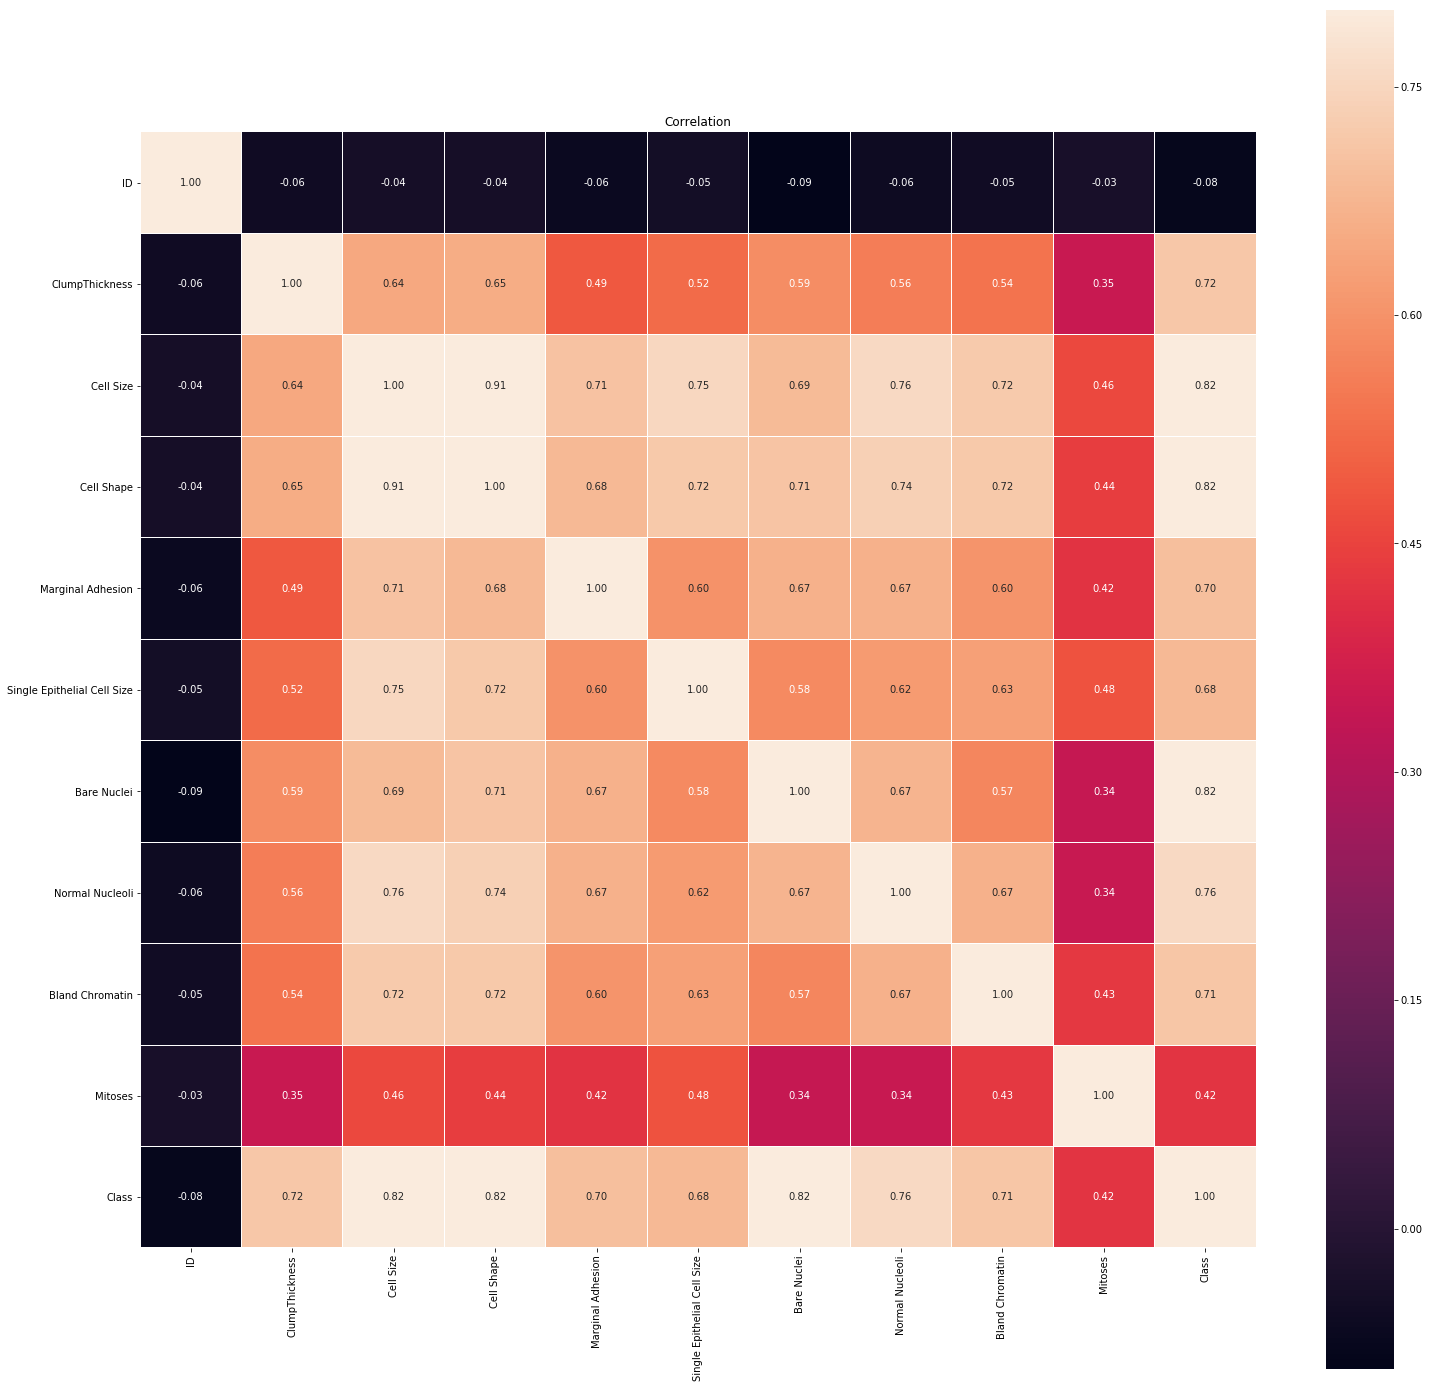

In [20]:
from matplotlib import pyplot as plt
plt.figure(figsize=(25, 25))
ax = sns.heatmap(df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

In [21]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [22]:
#Let us check for pair plots

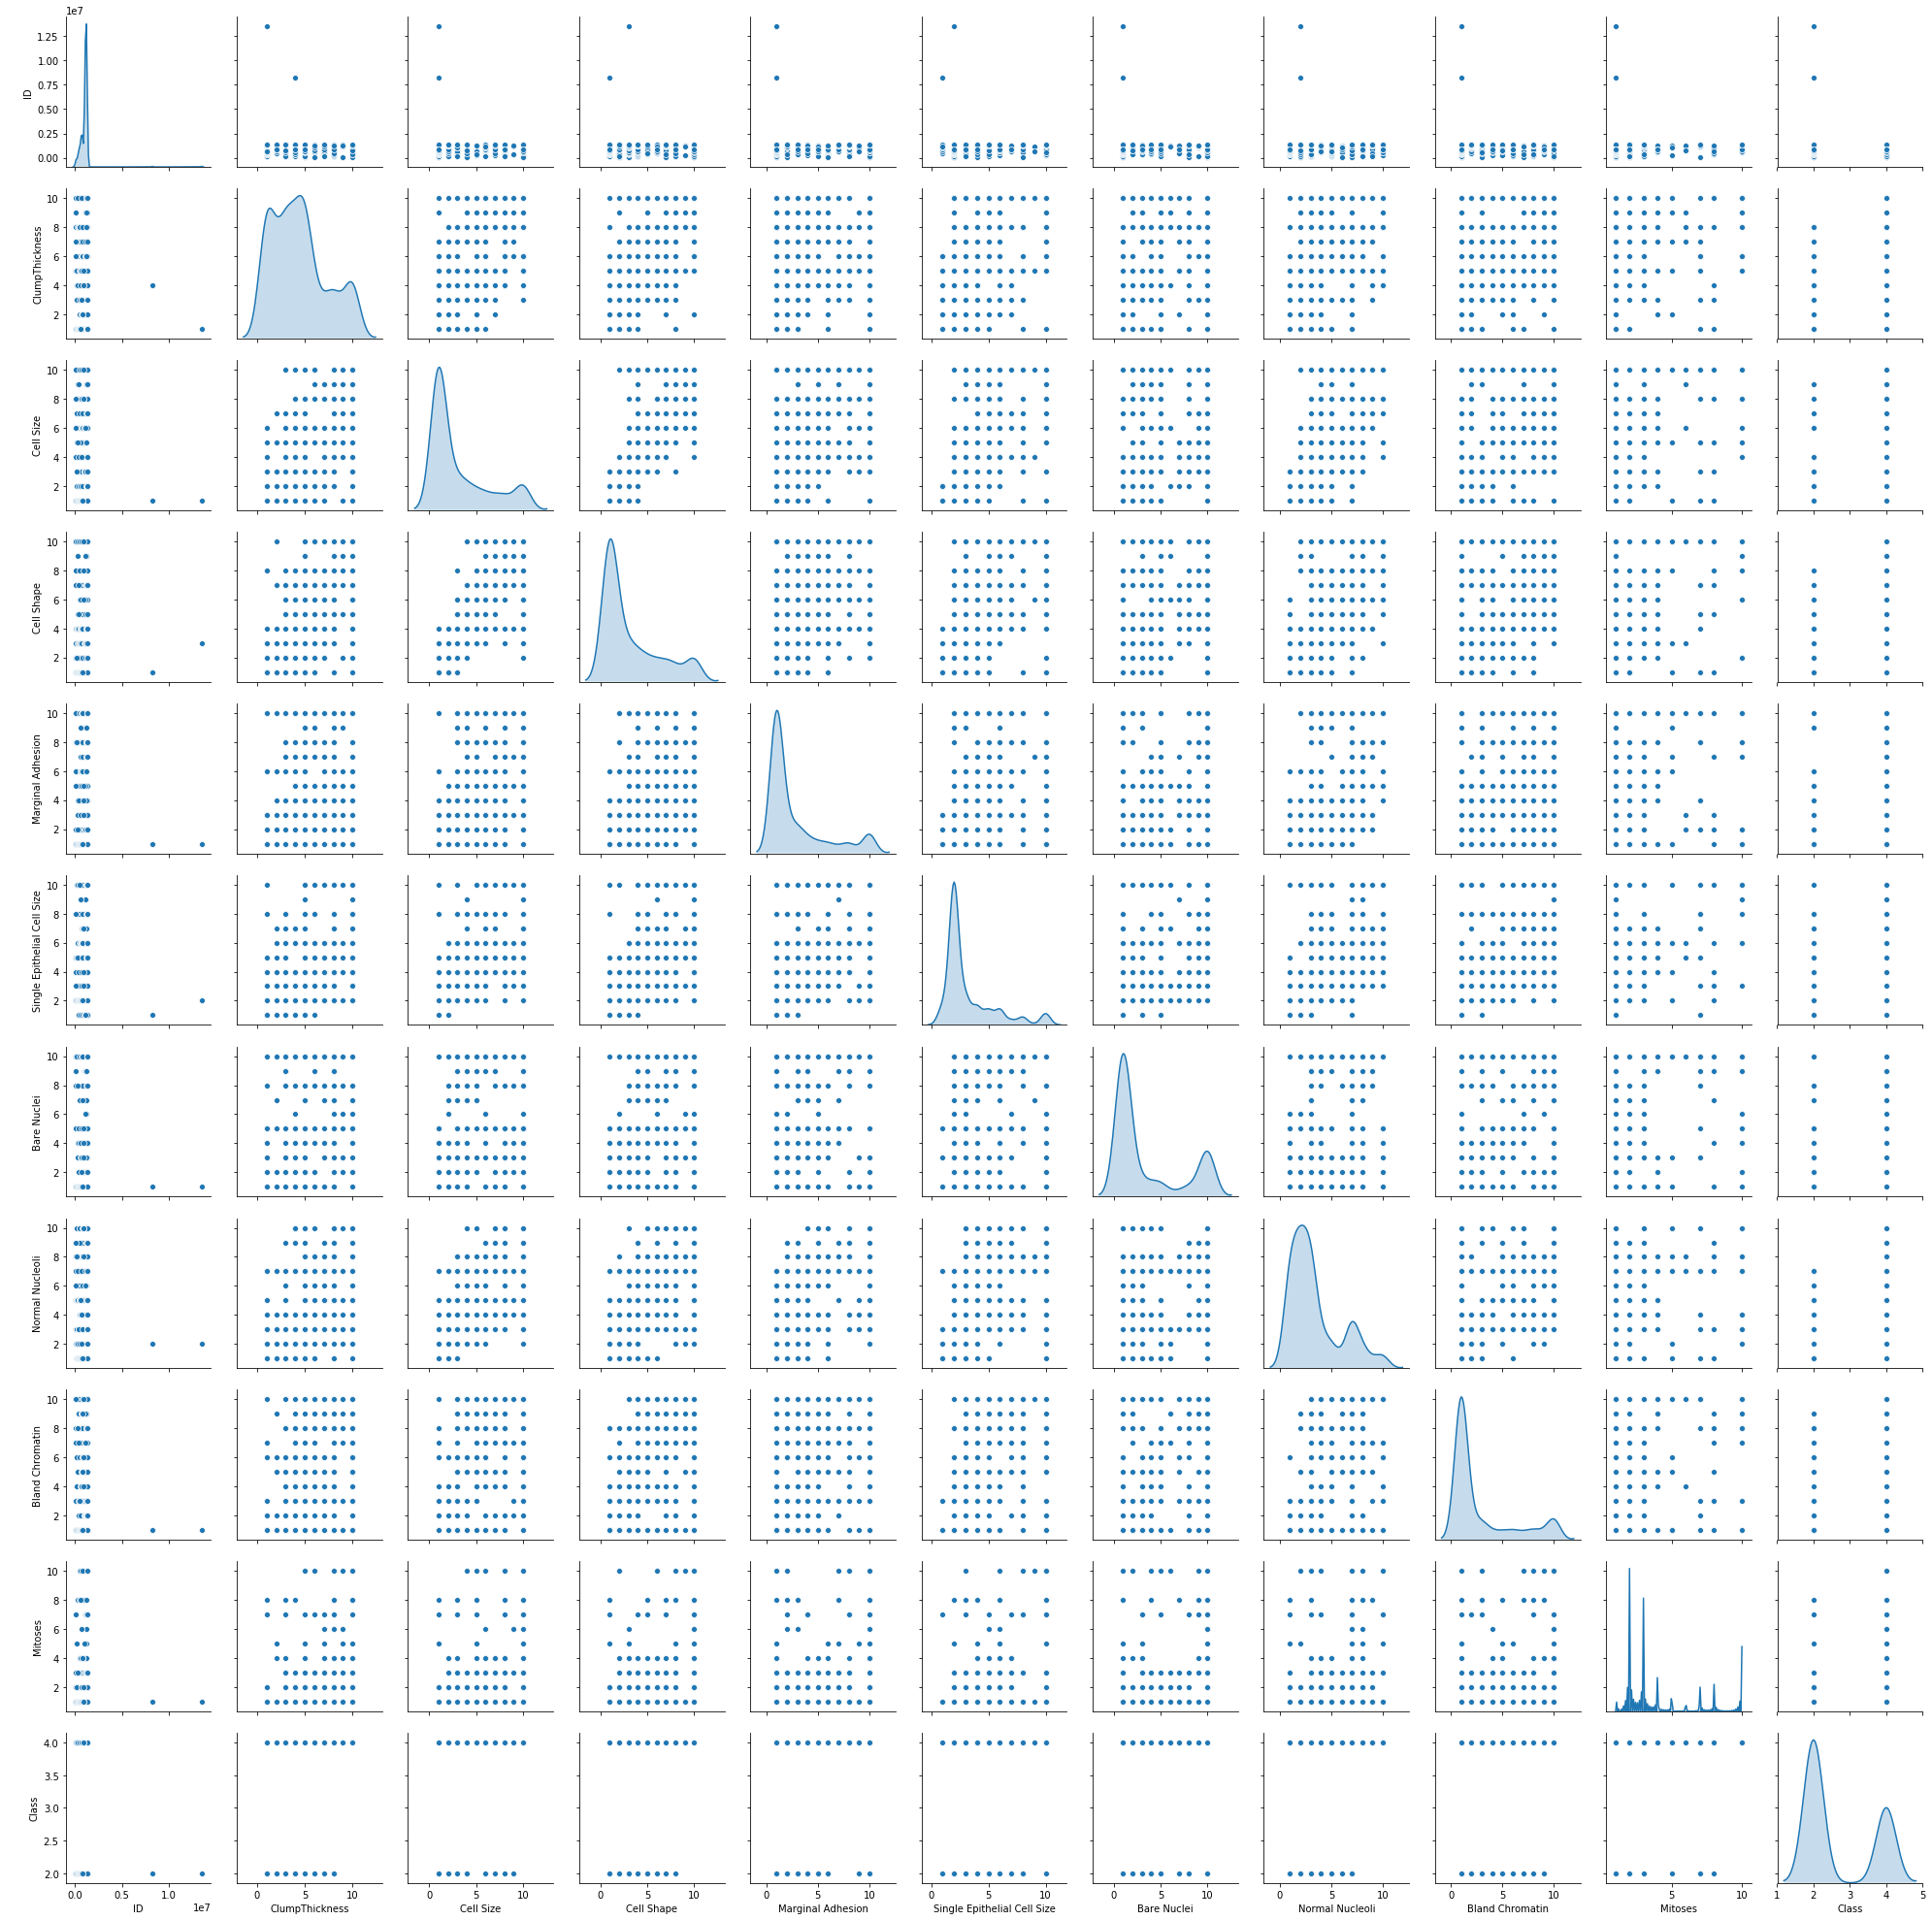

In [23]:
sns.pairplot(df, diag_kind='kde')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [24]:
cols = df.columns
cols

Index(['ID', 'ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses', 'Class'],
      dtype='object')

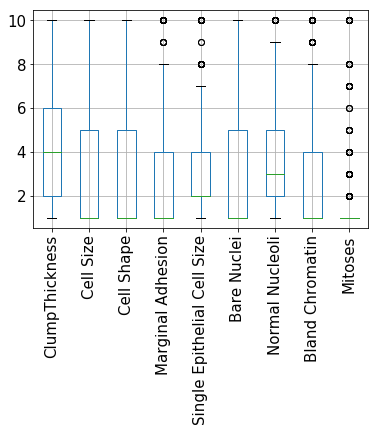

In [25]:
df.boxplot(column = ['ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses'],rot=90, fontsize=15)

In [26]:
pd.crosstab(df['Marginal Adhesion'], df['Class'])

Class,2,4
Marginal Adhesion,,
1,375,32
2,37,21
3,31,27
4,5,28
5,4,19
6,4,18
7,0,13
8,0,25
9,1,4


In [27]:
df['Marginal Adhesion'] = np.where(df['Marginal Adhesion'] > 5, 5, df['Marginal Adhesion'])
pd.crosstab(df['Marginal Adhesion'], df['Class'])

Class,2,4
Marginal Adhesion,,
1,375,32
2,37,21
3,31,27
4,5,28
5,10,133


In [28]:
pd.crosstab(df['Single Epithelial Cell Size'], df['Class'])

Class,2,4
Single Epithelial Cell Size,,
1,46,1
2,363,23
3,29,43
4,7,41
5,5,34
6,2,39
7,3,9
8,2,19
9,0,2


In [29]:
df['Single Epithelial Cell Size'] = np.where(df['Single Epithelial Cell Size'] > 5, 5, df['Single Epithelial Cell Size'])
pd.crosstab(df['Single Epithelial Cell Size'], df['Class'])

Class,2,4
Single Epithelial Cell Size,,
1,46,1
2,363,23
3,29,43
4,7,41
5,13,133


In [30]:
pd.crosstab(df['Normal Nucleoli'], df['Class'])

Class,2,4
Normal Nucleoli,,
1,150,2
2,159,7
3,129,36
4,8,32
5,4,30
6,1,9
7,7,66
8,0,28
9,0,11


In [31]:
df['Normal Nucleoli'] = np.where(df['Normal Nucleoli'] > 5, 5, df['Normal Nucleoli'])
pd.crosstab(df['Normal Nucleoli'], df['Class'])

Class,2,4
Normal Nucleoli,,
1,150,2
2,159,7
3,129,36
4,8,32
5,12,164


In [32]:
pd.crosstab(df['Bland Chromatin'], df['Class'])

Class,2,4
Bland Chromatin,,
1,402,41
2,30,6
3,12,32
4,1,17
5,2,17
6,4,18
7,2,14
8,4,20
9,1,15


In [33]:
df['Bland Chromatin'] = np.where(df['Bland Chromatin'] > 5, 5, df['Bland Chromatin'])
pd.crosstab(df['Bland Chromatin'], df['Class'])

Class,2,4
Bland Chromatin,,
1,402,41
2,30,6
3,12,32
4,1,17
5,13,145


In [34]:
pd.crosstab(df['Mitoses'], df['Class'])

Class,2,4
Mitoses,,
1,445,134
2,8,27
3,2,31
4,0,12
5,1,5
6,0,3
7,1,8
8,1,7
10,0,14


In [35]:
df['Mitoses'] = np.where(df['Mitoses'] > 5, 5, df['Mitoses'])
pd.crosstab(df['Mitoses'], df['Class'])

Class,2,4
Mitoses,,
1,445,134
2,8,27
3,2,31
4,0,12
5,3,37


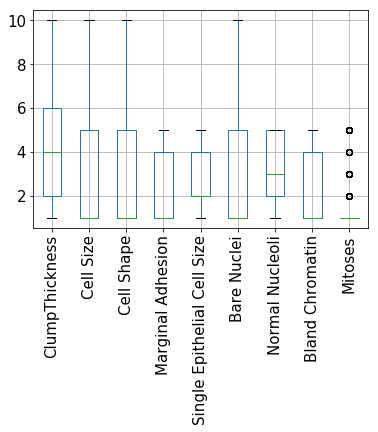

In [36]:
df.boxplot(column = ['ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses'],rot=90, fontsize=15)

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [38]:
# We could see most of the outliers are now removed.

In [39]:
X = df[df.columns[1:-1]]
y = df["Class"]

#X, y = df.iloc[:, 1:].values , df.iloc[:,0].values

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5 , random_state=0)
#sc = StandardScaler()
#X_train_std = sc.fit_transform(X_train)
#X_test_std = sc.fit_transform(X_test)

#sc = StandardScaler()
#X_std =  sc.fit_transform(X)
X_std = X.apply(zscore)

In [40]:
X_std.shape

(699, 9)

# Q6 Create a covariance matrix for identifying Principal components

In [41]:
# PCA
# Step 1 - Create covariance matrix

In [42]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.5412577  0.5759771  0.5908535
  0.57367417 0.56679455 0.39012503]
 [0.64583645 1.00143266 0.90818117 0.72835309 0.78893865 0.68765657
  0.71445936 0.73114712 0.49803826]
 [0.65552689 0.90818117 1.00143266 0.70884596 0.76479818 0.70848734
  0.70097947 0.72305564 0.47382672]
 [0.5412577  0.72835309 0.70884596 1.00143266 0.69551948 0.7003226
  0.65818904 0.66502316 0.41573208]
 [0.5759771  0.78893865 0.76479818 0.69551948 1.00143266 0.67329762
  0.67022089 0.72186739 0.46488937]
 [0.5908535  0.68765657 0.70848734 0.7003226  0.67329762 1.00143266
  0.69013785 0.63439548 0.41418324]
 [0.57367417 0.71445936 0.70097947 0.65818904 0.67022089 0.69013785
  1.00143266 0.67912177 0.37551116]
 [0.56679455 0.73114712 0.72305564 0.66502316 0.72186739 0.63439548
  0.67912177 1.00143266 0.45532997]
 [0.39012503 0.49803826 0.47382672 0.41573208 0.46488937 0.41418324
  0.37551116 0.45532997 1.00143266]]


# Q7 Identify eigen values and eigen vector

In [43]:
# Step 2- Get eigen values and eigen vector

In [44]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30283936 -0.04718319  0.01090492  0.9092239  -0.02945181 -0.13365559
  -0.07267835  0.23502062  0.0026427 ]
 [-0.37118847 -0.01685261  0.72961247 -0.01763084  0.34778059  0.20165823
  -0.12272942 -0.32457304 -0.21739906]
 [-0.36816937 -0.04938305 -0.67081723  0.03587609  0.31545784  0.35450759
  -0.02825839 -0.35689851 -0.23951079]
 [-0.33779016 -0.12702987 -0.05120416 -0.29583003 -0.28746144 -0.07842534
  -0.54859265  0.44078682 -0.44225832]
 [-0.35152491 -0.02596197 -0.06891654 -0.19462803  0.29668409 -0.75614222
   0.4001622   0.03013819 -0.11097771]
 [-0.33638759 -0.14907673  0.08647577 -0.03497453 -0.65004219  0.23677514
   0.59185697 -0.09435981 -0.13454545]
 [-0.33514082 -0.22714697 -0.04190069 -0.09008782 -0.26098653 -0.21557348
  -0.36468339 -0.402323    0.64557706]
 [-0.34081926 -0.02130272  0.01613763 -0.19003477  0.29920659  0.3672575
   0.17573756  0.58609074  0.49822293]
 [-0.235909    0.9507718  -0.02618144 -0.02943174 -0.16678932 -0.02191912
  -0.

In [45]:
print("Eigen Values:")
pd.DataFrame(eigenvalues).transpose()

Eigen Values:


,0,1,2,3,4,5,6,7,8
0,6.095221,0.715538,0.089226,0.504713,0.410228,0.249519,0.279686,0.313074,0.355688


# Q8 Find variance and cumulative variance by each eigen vector

In [46]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [0.67627794 0.75566843 0.81166746 0.85718314 0.89664745 0.9313837
 0.96241549 0.9901002  1.        ]


In [47]:
cum_var_exp.size

9

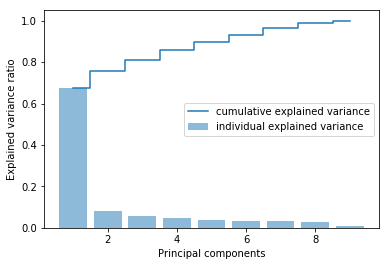

In [48]:
plt.bar(range(1,len(var_explained) + 1), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,cum_var_exp.size + 1),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [49]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(6.095221371593258, array([-0.30283936, -0.37118847, -0.36816937, -0.33779016, -0.35152491,
       -0.33638759, -0.33514082, -0.34081926, -0.235909  ])), (0.7155380889646562, array([-0.04718319, -0.01685261, -0.04938305, -0.12702987, -0.02596197,
       -0.14907673, -0.22714697, -0.02130272,  0.9507718 ])), (0.5047133507732121, array([ 0.9092239 , -0.01763084,  0.03587609, -0.29583003, -0.19462803,
       -0.03497453, -0.09008782, -0.19003477, -0.02943174])), (0.4102279120927304, array([-0.02945181,  0.34778059,  0.31545784, -0.28746144,  0.29668409,
       -0.65004219, -0.26098653,  0.29920659, -0.16678932])), (0.3556876634405965, array([ 0.0026427 , -0.21739906, -0.23951079, -0.44225832, -0.11097771,
       -0.13454545,  0.64557706,  0.49822293,  0.06601872])), (0.3130741329220896, array([ 0.23502062, -0.32457304, -0.35689851,  0.44078682,  0.03013819,
       -0.09435981, -0.402323  ,  0.58609074, -0.05069361])), (0.27968624616637455, array([-0.07267835, -0.12272942, -0.02825839, -0

In [77]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:9])   # Reducing from 8 to 4 dimension space

X_std_9D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_9D)  # converting array to dataframe for pairplot

In [53]:
Proj_data_df.shape, y.shape

((699, 4), (699,))

In [79]:
Proj_data_df.head()

,0,1,2,3,4,5,6,7,8,Class
0,1.473790,-0.131356,0.673692,-0.166806,0.498005,-0.155368,-0.279177,-0.332484,0.007342,2
1,-1.945266,-0.953269,-0.684232,-0.964368,-1.337954,0.432244,0.725319,-0.908130,-0.012857,2
2,1.596107,-0.139007,0.017751,-0.325474,0.458953,-0.348492,-0.063991,-0.172061,0.023484,2
3,-1.716797,-0.497621,0.408448,1.768509,0.427429,-0.314353,0.564911,1.408863,0.162077,2
4,1.166543,-0.270606,-0.012787,-0.509401,-0.046119,0.302483,-0.927132,-0.381305,-0.059423,2


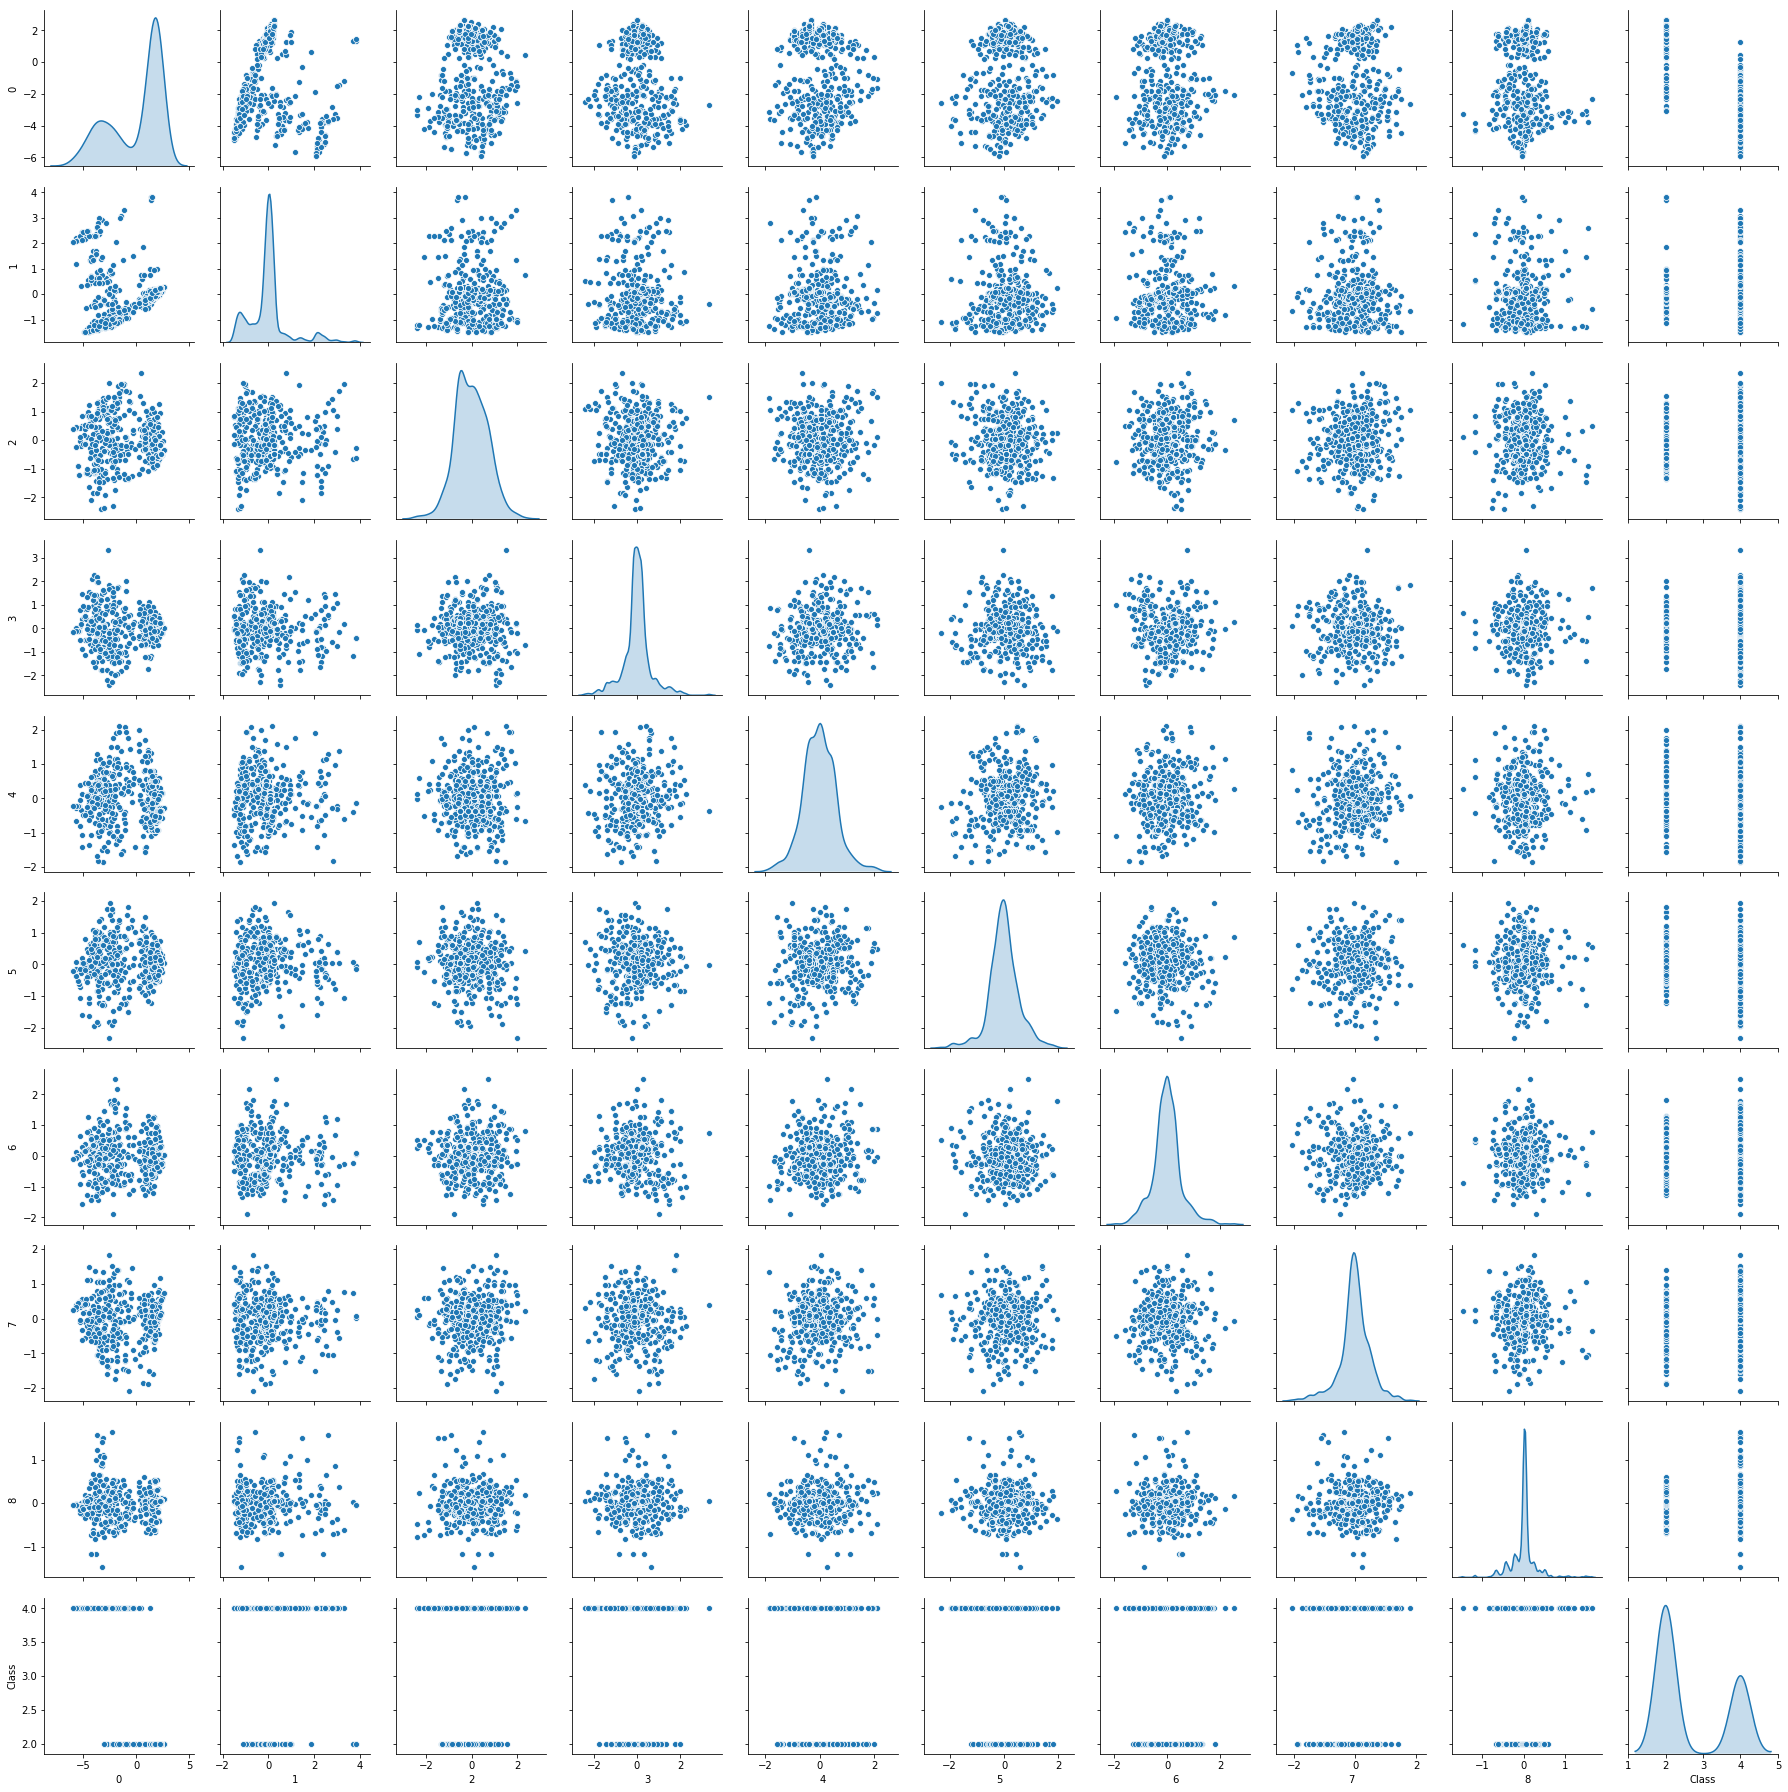

In [78]:
#Let us check it visually
Proj_data_df = Proj_data_df.join(y)
sns.pairplot(Proj_data_df, diag_kind='kde') 
#Proj_data_df

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [56]:
from sklearn.decomposition import PCA

In [67]:
pca = PCA(n_components=7)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=7, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [68]:
X_pca = pca.transform(X_std)

In [69]:
X_pca.shape

(699, 7)

# Q10 Find correlation between components and features

In [70]:
pca.components_

array([[ 0.30283936,  0.37118847,  0.36816937,  0.33779016,  0.35152491,
         0.33638759,  0.33514082,  0.34081926,  0.235909  ],
       [-0.04718319, -0.01685261, -0.04938305, -0.12702987, -0.02596197,
        -0.14907673, -0.22714697, -0.02130272,  0.9507718 ],
       [-0.9092239 ,  0.01763084, -0.03587609,  0.29583003,  0.19462803,
         0.03497453,  0.09008782,  0.19003477,  0.02943174],
       [-0.02945181,  0.34778059,  0.31545784, -0.28746144,  0.29668409,
        -0.65004219, -0.26098653,  0.29920659, -0.16678932],
       [ 0.0026427 , -0.21739906, -0.23951079, -0.44225832, -0.11097771,
        -0.13454545,  0.64557706,  0.49822293,  0.06601872],
       [-0.23502062,  0.32457304,  0.35689851, -0.44078682, -0.03013819,
         0.09435981,  0.402323  , -0.58609074,  0.05069361],
       [-0.07267835, -0.12272942, -0.02825839, -0.54859265,  0.4001622 ,
         0.59185697, -0.36468339,  0.17573756, -0.0600066 ]])

In [71]:
pca.explained_variance_

array([6.09522137, 0.71553809, 0.50471335, 0.41022791, 0.35568766,
       0.31307413, 0.27968625])

In [72]:
pca.explained_variance_ratio_

array([0.67627794, 0.07939049, 0.05599903, 0.04551567, 0.03946431,
       0.03473625, 0.03103179])

              0             1             2             3             4  \
0  1.000000e+00  1.434453e-14  1.197048e-17  5.449874e-16 -1.097538e-16   
1  1.434453e-14  1.000000e+00  2.016838e-16  2.935796e-17 -7.566853e-17   
2  1.197048e-17  2.016838e-16  1.000000e+00  4.858862e-17  1.745625e-16   
3  5.449874e-16  2.935796e-17  4.858862e-17  1.000000e+00  2.199098e-16   
4 -1.097538e-16 -7.566853e-17  1.745625e-16  2.199098e-16  1.000000e+00   
5 -2.046086e-16 -3.696643e-16 -2.414827e-16 -7.987866e-16 -8.733364e-16   
6 -1.704041e-15  1.930646e-16 -1.566385e-16 -1.084722e-16 -2.545430e-16   

              5             6  
0 -2.046086e-16 -1.704041e-15  
1 -3.696643e-16  1.930646e-16  
2 -2.414827e-16 -1.566385e-16  
3 -7.987866e-16 -1.084722e-16  
4 -8.733364e-16 -2.545430e-16  
5  1.000000e+00  1.435182e-16  
6  1.435182e-16  1.000000e+00  


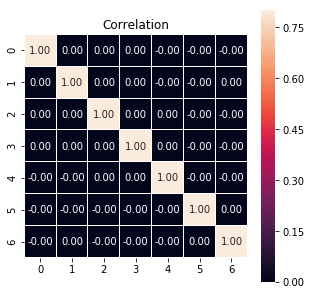

In [73]:
from matplotlib import pyplot as plt
X_pca_df = pd.DataFrame(X_pca)  # converting array to dataframe for pairplot
print(X_pca_df.corr())
plt.figure(figsize=(5, 5))
ax = sns.heatmap(X_pca_df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

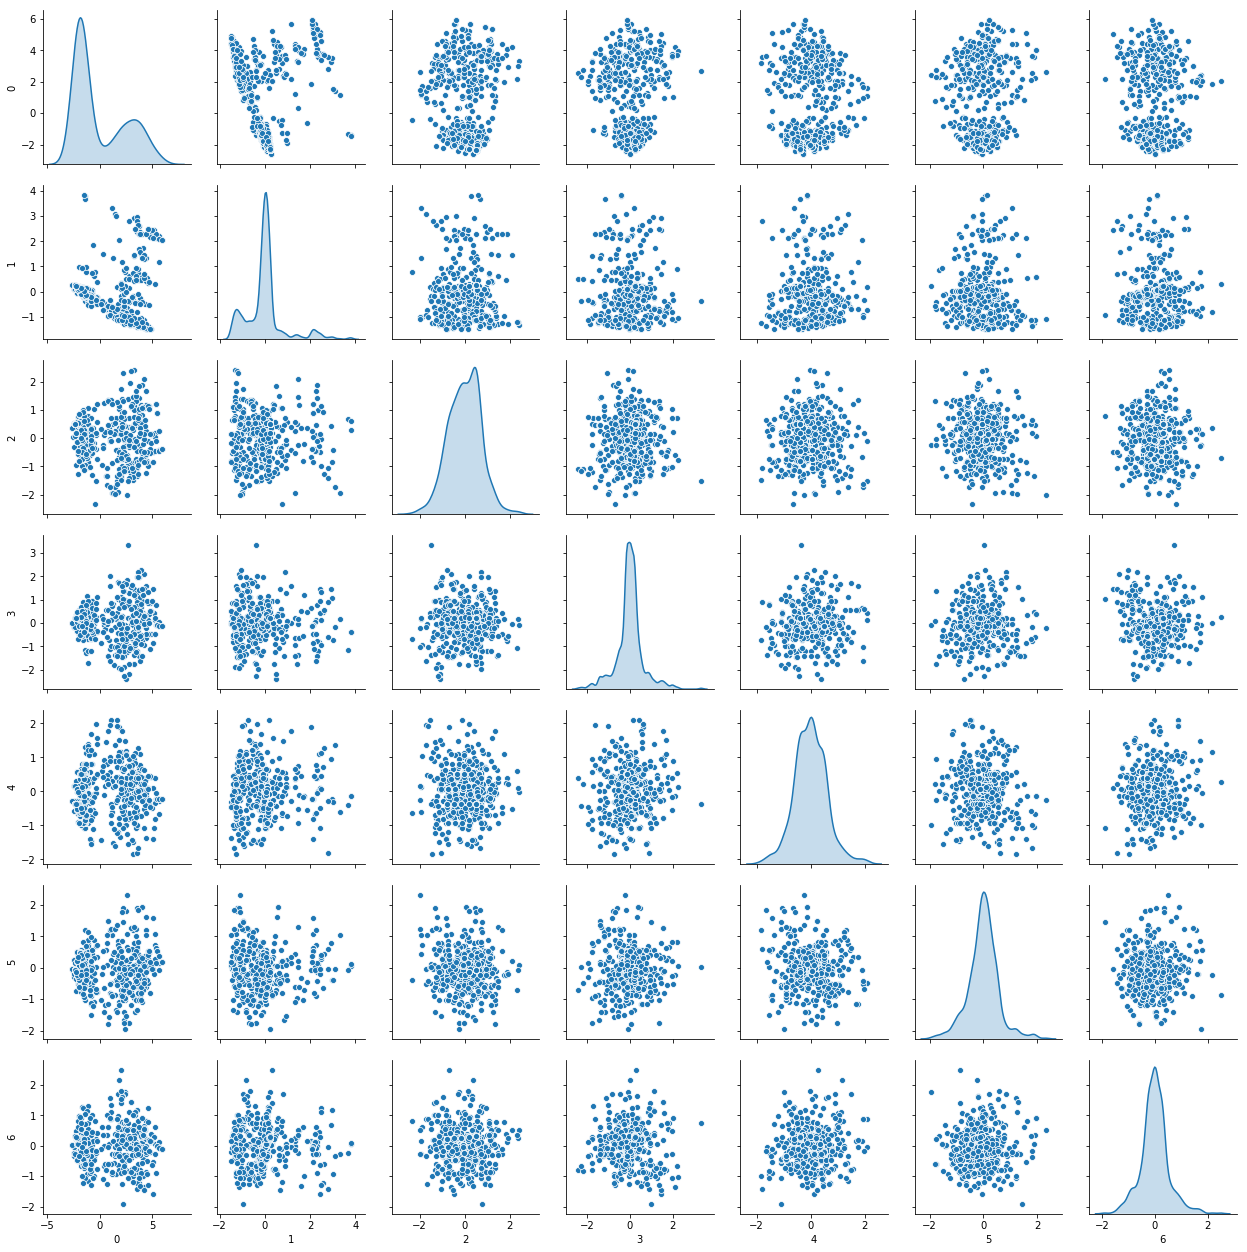

In [74]:
#Let us check it visually
sns.pairplot(X_pca_df, diag_kind='kde') 

In [75]:
# OBSERVATIONS -

# 1. There is a significant correlation between target (Class) and first PCA (pc0)
# 2. Correlation between other PCA dimensions and mpg is very low 
# 3. What was clearly visible as separate gaussians in original dimension is not visible any more. This is due to the fact that
#    PCA dimesions are composite of the original dimensions
